# 03 — dGNSS bias-corrected DTM

Step 02 left two strong photogrammetric DTMs (SMRF and a retuned CSF), both with a
small residual bias vs the 42 dGNSS points. Rather than splice in the dGNSS-DTM
(circular, partial coverage), we use the dGNSS points as **control** to model and
remove that residual:

$$\text{corrected}(x,y) = \text{base}(x,y) + C(x,y)$$

The residual is dominated by a **constant offset + tilt** — a small datum/
georeferencing discrepancy — so the right $C$ is a low-order **polynomial trend**,
not a wiggly local surface. We confirm with leave-one-out CV, pick the model the
data supports, and apply it. SMRF vs CSF-retuned is decided on a common-subset LOO
comparison plus coverage.

**Inputs:** `outputs/02_dtm/talar_{smrf,csf_retuned}_dtm_0p5m.tif`,
`data/20250521.gpkg::puntos`, `outputs/02_dtm/dgnss_with_density.csv`,
`outputs/02_dtm/pastizal_smrf_dtm_0p5m.tif`.

**Outputs:** `outputs/03_hybrid/` — corrected talar DTMs (both bases), the
correction surface, `loo_validation.csv`, the canonical production DTM, and the
pastizal DTM (SMRF-raw, uncorrected).

In [1]:
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio

from drone_reserve.hybrid import (
    compute_residuals, compare_models, leave_one_out, apply_correction, CorrectionModel,
)
from drone_reserve.dtm import residual_stats, fill_dtm_voids

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "pyproject.toml").is_file():
        REPO = parent; break
else:
    raise RuntimeError("repo root not found")

DATA = REPO / "data"
DTM2 = REPO / "outputs" / "02_dtm"
OUT  = REPO / "outputs" / "03_hybrid"
FIGS = OUT / "figs"
OUT.mkdir(parents=True, exist_ok=True); FIGS.mkdir(parents=True, exist_ok=True)

BASES = {"SMRF": DTM2 / "talar_smrf_dtm_0p5m.tif",
         "CSF-retuned": DTM2 / "talar_csf_retuned_dtm_0p5m.tif"}

# Flight footprints (EPSG:32721) for clipping the filled DTMs to the flown area.
_area = gpd.read_file(DATA / "Area.shp").to_crs(32721)
TALAR_GEOM = [_area.loc[_area["id"] == 1, "geometry"].iloc[0].__geo_interface__]
PAST_GEOM  = [_area.loc[_area["id"] == 2, "geometry"].iloc[0].__geo_interface__]

def xy_to_px(xy, raster_path):
    """World (x,y) -> (cols, rows) pixel coords for overlaying on imshow."""
    with rasterio.open(raster_path) as src:
        inv = ~src.transform
    cols, rows = [], []
    for x, y in xy:
        c, r = inv * (x, y)
        cols.append(c); rows.append(r)
    return cols, rows

print("OK")

OK


## Control points + residuals

42 dGNSS points, with the canopy-density class from step 02 for stratified reporting.

In [2]:
puntos = gpd.read_file(DATA / "20250521.gpkg", layer="puntos")
puntos = puntos[puntos["Name"].astype(str).str.isnumeric()].copy()
puntos["Name"] = puntos["Name"].astype(int)
dens = pd.read_csv(DTM2 / "dgnss_with_density.csv")[["Name", "density_class"]]
puntos = puntos.merge(dens, on="Name", how="left").sort_values("Name").reset_index(drop=True)
assert len(puntos) == 42

res = {label: compute_residuals(path, puntos) for label, path in BASES.items()}
for label, r in res.items():
    print(f"{label:12s} n_valid={r.n_valid}/{r.n_total} (dropped {r.n_dropped})  "
          f"residual mean={r.residual.mean():+.3f}  std={r.residual.std():.3f}")

SMRF         n_valid=40/42 (dropped 2)  residual mean=-0.239  std=0.357
CSF-retuned  n_valid=36/42 (dropped 6)  residual mean=-0.156  std=0.269


C:\Users\paco_\miniforge3\envs\drone-reserve\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


## Model comparison by leave-one-out CV

Each candidate correction is fit leaving out one control point at a time and scored at
the held-out point — so a model that merely interpolates its own control gets no credit.
We score on the **common subset** of points valid in both bases, so SMRF and CSF-retuned
are compared on identical points.

In [3]:
common = np.intersect1d(res["SMRF"].ids, res["CSF-retuned"].ids)
print(f"Common control points: {len(common)}\n")

MODELS = [
    CorrectionModel("poly", degree=0),   # debias
    CorrectionModel("poly", degree=1),   # affine (tilt) -- production candidate
    CorrectionModel("poly", degree=2),   # quadratic
    CorrectionModel("tps", smoothing=1.0),
    CorrectionModel("tps", smoothing=10.0),
]
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
tables = {}
for label in BASES:
    tbl, _ = compare_models(res[label], MODELS, restrict_ids=common)
    tables[label] = tbl
    print(f"=== {label} (LOO on {len(common)} common pts) ===")
    print(tbl.to_string()); print()

Common control points: 35



=== SMRF (LOO on 35 common pts) ===
             n  rmse   mae   bias
model                            
base (raw)  35 0.354 0.268  0.196
debias      35 0.305 0.238 -0.043
affine      35 0.250 0.206 -0.037
quadratic   35 0.226 0.181 -0.008
tps(s=1)    35 0.350 0.261 -0.006
tps(s=10)   35 0.316 0.244 -0.005

=== CSF-retuned (LOO on 35 common pts) ===
             n  rmse   mae  bias
model                           
base (raw)  35 0.306 0.237 0.173
debias      35 0.260 0.216 0.018
affine      35 0.210 0.163 0.009
quadratic   35 0.204 0.167 0.013
tps(s=1)    35 0.321 0.260 0.017
tps(s=10)   35 0.301 0.243 0.021



### Model + base choice

- **Model = affine (degree-1 trend).** Quadratic is marginally lower in-sample, but the
  correction is applied *globally* across the talar — most of which lies outside the
  control hull. A plane extrapolates safely; a quadratic does not. TPS is worse than the
  trend models, confirming the residual is a global tilt, not a local surface.
- **Both bases improve ~30%** under the affine correction and end bias-free. CSF-retuned
  is a touch more accurate at control points, but SMRF has better **coverage** (40 vs 36
  control points; fewer dense-canopy gaps) — which matters more for the complete DTM that
  feeds the CHM and hydrology. We write **both** corrected products and bless
  **SMRF + affine** as the canonical talar DTM, keeping CSF-retuned + affine as an
  independent cross-check.

In [4]:
# Stratified LOO (Alta/Baja) for the chosen affine model — ties to the poster's split.
AFFINE = CorrectionModel("poly", degree=1)
strat_rows = []
for label, r in res.items():
    loo, _, _ = leave_one_out(r, AFFINE)
    dclass = puntos.set_index("Name").loc[r.ids, "density_class"].to_numpy()
    for subset in ["Full", "Alta", "Baja"]:
        m = np.ones(r.n_valid, bool) if subset == "Full" else (dclass == subset)
        sb = residual_stats(r.base_z[m], r.ref_z[m])
        sc = residual_stats(loo[m], r.ref_z[m])
        strat_rows.append({"base": label, "subset": subset, "n": int(m.sum()),
                           "base_rmse": sb.rmse, "affine_loo_rmse": sc.rmse})
stratified = pd.DataFrame(strat_rows).set_index(["base", "subset"])
stratified

n  base_rmse  affine_loo_rmse
base        subset                                
SMRF        Full    40      0.429            0.310
            Alta    20      0.583            0.379
            Baja    20      0.167            0.219
CSF-retuned Full    36      0.311            0.218
            Alta    16      0.414            0.236
            Baja    20      0.192            0.202

## Apply the affine correction, fill voids, and write continuous products

The ground filters only produce ground where ground returns exist, so the corrected
DTM has nodata gaps (mostly small inter-point holes; the strict IDW radius leaves cells
empty unless a ground point is within ~0.7 m). A continuous DTM is required for the CHM
(`CHM = DSM − DTM` would inherit every gap). We fill **only the empty cells** with
`fill_dtm_voids` (rasterio fillnodata) — leaving the accurate measured cells untouched,
so coverage reaches ~100% at ~no accuracy cost (RMSE 0.43 → 0.44, vs 0.61 if we had used
a wider IDW radius). A companion confidence raster records each pixel's distance to the
nearest measured ground, flagging interpolated terrain.

In [5]:
# Apply the affine correction, then fill voids -> continuous, CHM-ready DTMs.
# Correction is applied to the strict (accurate) base; fill only touches empty cells,
# so measured-ground fidelity is preserved (RMSE ~0.44) while coverage reaches ~100%.

def correct_then_fill(base_path, res_obj, final_name, geom):
    gappy = OUT / ("_tmp_" + final_name)
    cr = apply_correction(base_path, res_obj, gappy, AFFINE)
    fr = fill_dtm_voids(gappy, OUT / final_name, clip_geometry=geom, max_search_distance_px=100)
    gappy.unlink()  # drop the intermediate gappy raster
    Path(str(gappy).replace(".tif", "_confidence.tif")).unlink(missing_ok=True)
    return cr, fr

cr_smrf, fr_smrf = correct_then_fill(BASES["SMRF"], res["SMRF"],
                                     "talar_dtm_corrected_0p5m.tif", TALAR_GEOM)
cr_csf, fr_csf = correct_then_fill(BASES["CSF-retuned"], res["CSF-retuned"],
                                   "talar_csf_dtm_corrected_0p5m.tif", TALAR_GEOM)
# Pastizal: uncorrected (no dGNSS), but still gap-filled for a continuous CHM.
fr_past = fill_dtm_voids(DTM2 / "pastizal_smrf_dtm_0p5m.tif", OUT / "pastizal_dtm_0p5m.tif",
                         clip_geometry=PAST_GEOM, max_search_distance_px=100)

CANONICAL = OUT / "talar_dtm_corrected_0p5m.tif"  # SMRF + affine + fill -> feeds CHM/hydrology
print(f"Canonical talar DTM: {CANONICAL.name}  (SMRF + affine, gap-filled)")
for name, fr in [("talar SMRF", fr_smrf), ("talar CSF", fr_csf), ("pastizal", fr_past)]:
    print(f"  {name:11s}: measured {fr.pct_measured:5.1f}%  filled {fr.pct_filled:4.1f}%  "
          f"unfilled {fr.pct_unfilled:.2f}%  max fill dist {fr.max_fill_distance_m:.1f} m")
print(f"  max |affine correction| (SMRF): {cr_smrf.max_abs_correction:.3f} m")

Canonical talar DTM: talar_dtm_corrected_0p5m.tif  (SMRF + affine, gap-filled)
  talar SMRF : measured  62.9%  filled 37.1%  unfilled 0.00%  max fill dist 23.0 m
  talar CSF  : measured  57.2%  filled 42.8%  unfilled 0.00%  max fill dist 23.0 m
  pastizal   : measured  66.7%  filled 33.3%  unfilled 0.01%  max fill dist 49.9 m
  max |affine correction| (SMRF): 1.027 m


## Figures

C:\Users\paco_\AppData\Local\Temp\ipykernel_26292\391338173.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIGS / "before_after_scatter.png", dpi=150); fig.show()


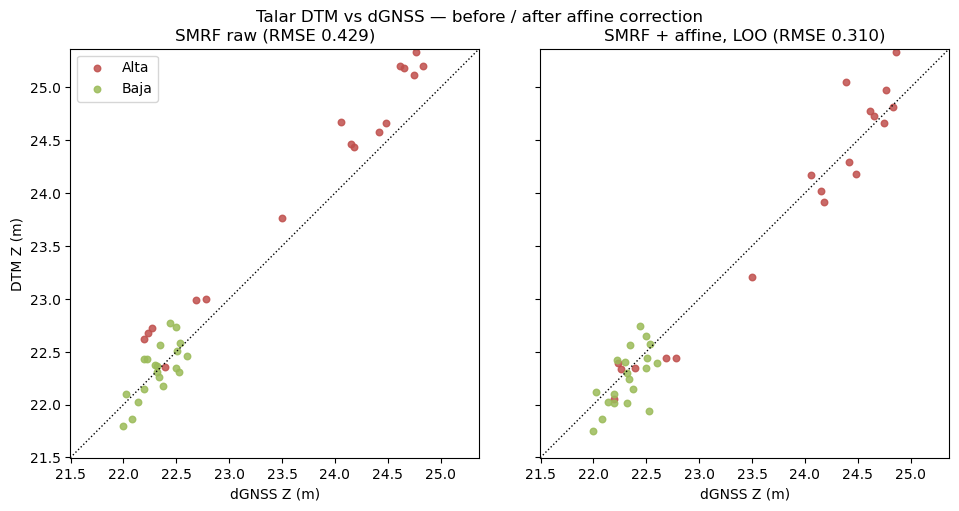

In [6]:
# Before/after: base vs corrected at control points (canonical SMRF + affine).
r = res["SMRF"]
loo, sc, sb = leave_one_out(r, AFFINE)
dclass = puntos.set_index("Name").loc[r.ids, "density_class"].to_numpy()
lo, hi = r.ref_z.min() - 0.5, r.ref_z.max() + 0.5
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
for ax, zz, title in [(axes[0], r.base_z, f"SMRF raw (RMSE {sb.rmse:.3f})"),
                      (axes[1], loo, f"SMRF + affine, LOO (RMSE {sc.rmse:.3f})")]:
    for cls, c in [("Alta", "#c0504d"), ("Baja", "#9bbb59")]:
        m = dclass == cls
        ax.scatter(r.ref_z[m], zz[m], s=22, color=c, label=cls, alpha=0.85)
    ax.plot([lo, hi], [lo, hi], "k:", lw=1)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal", "box")
    ax.set_xlabel("dGNSS Z (m)"); ax.set_title(title)
axes[0].set_ylabel("DTM Z (m)"); axes[0].legend()
fig.suptitle("Talar DTM vs dGNSS — before / after affine correction")
fig.tight_layout(); fig.savefig(FIGS / "before_after_scatter.png", dpi=150); fig.show()

C:\Users\paco_\AppData\Local\Temp\ipykernel_26292\109530137.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIGS / "correction_surface.png", dpi=150); fig.show()


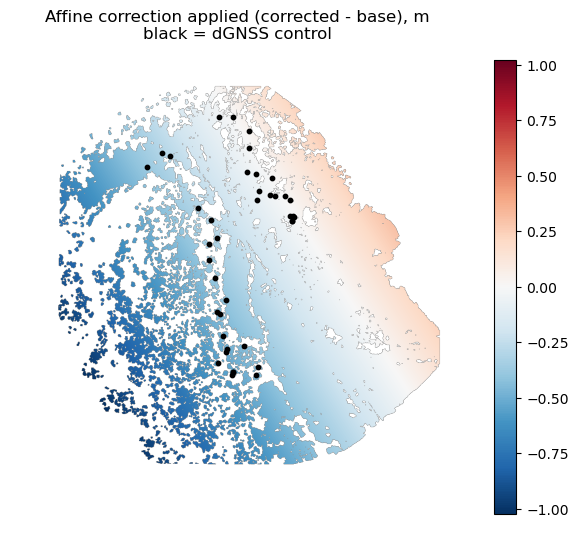

In [7]:
# The correction surface itself (the recovered tilt) over the canonical DTM extent.
with rasterio.open(BASES["SMRF"]) as src:
    base = src.read(1, masked=True)
with rasterio.open(CANONICAL) as src:
    corr_dtm = src.read(1, masked=True)
delta = corr_dtm - base
vmax = float(np.nanmax(np.abs(delta)))
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(delta, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
cols, rows = xy_to_px(res["SMRF"].xy, CANONICAL)
ax.scatter(cols, rows, s=10, c="k")
ax.set_title("Affine correction applied (corrected - base), m\nblack = dGNSS control")
fig.colorbar(im, ax=ax, shrink=0.8); ax.set_axis_off()
fig.tight_layout(); fig.savefig(FIGS / "correction_surface.png", dpi=150); fig.show()

C:\Users\paco_\AppData\Local\Temp\ipykernel_26292\527752239.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIGS / "dtm_filled_and_confidence.png", dpi=140); fig.show()


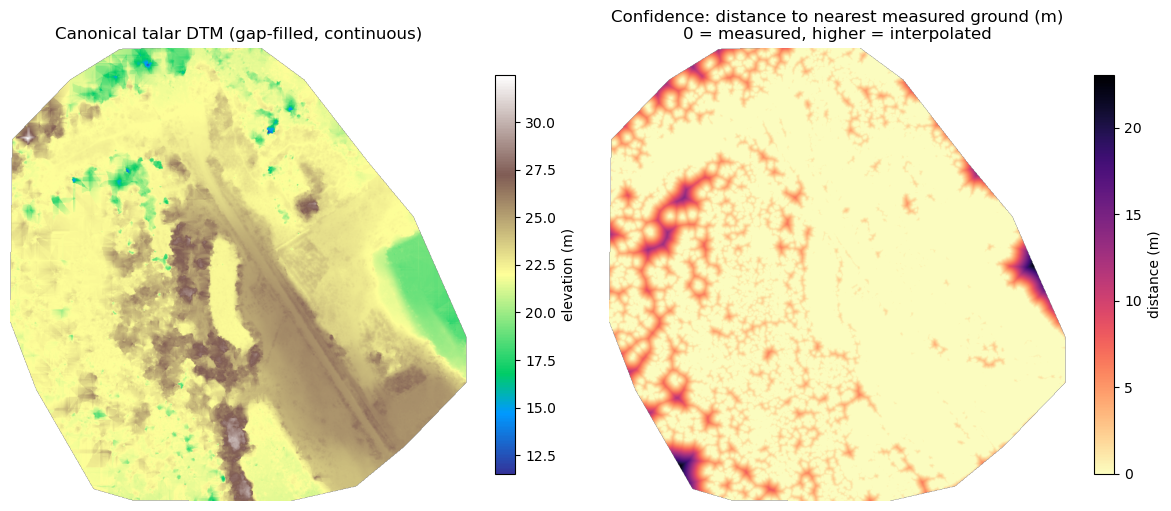

In [8]:
# Continuity check: the filled canonical DTM vs its distance-to-measured confidence.
import rasterio
from rasterio.mask import mask as rio_mask
conf_path = CANONICAL.with_name(CANONICAL.stem + "_confidence.tif")
with rasterio.open(CANONICAL) as src:
    dtm_c, tr = rio_mask(src, TALAR_GEOM, crop=True, filled=True, nodata=src.nodata)
    ndv = src.nodata
with rasterio.open(conf_path) as src:
    conf_c, _ = rio_mask(src, TALAR_GEOM, crop=True, filled=True, nodata=src.nodata)
dtm_disp = np.where((dtm_c[0] != ndv) & np.isfinite(dtm_c[0]), dtm_c[0], np.nan)
conf_disp = np.where((conf_c[0] != ndv) & np.isfinite(conf_c[0]), conf_c[0], np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
im0 = axes[0].imshow(dtm_disp, cmap="terrain")
axes[0].set_title("Canonical talar DTM (gap-filled, continuous)")
fig.colorbar(im0, ax=axes[0], shrink=0.7, label="elevation (m)")
im1 = axes[1].imshow(conf_disp, cmap="magma_r")
axes[1].set_title("Confidence: distance to nearest measured ground (m)\n0 = measured, higher = interpolated")
fig.colorbar(im1, ax=axes[1], shrink=0.7, label="distance (m)")
for ax in axes: ax.set_axis_off()
fig.tight_layout(); fig.savefig(FIGS / "dtm_filled_and_confidence.png", dpi=140); fig.show()

In [9]:
# Persist LOO validation for the report.
loo_rows = []
for label, r in res.items():
    for model in [CorrectionModel("poly", 0), AFFINE, CorrectionModel("poly", 2)]:
        lo_, sc_, sb_ = leave_one_out(r, model)
        loo_rows.append({"base": label, "model": model.label(), "n": r.n_valid,
                         "base_rmse": sb_.rmse, "loo_rmse": sc_.rmse,
                         "loo_bias": sc_.bias, "improvement_m": sb_.rmse - sc_.rmse})
loo_df = pd.DataFrame(loo_rows)
loo_df.to_csv(OUT / "loo_validation.csv", index=False)
stratified.to_csv(OUT / "loo_stratified.csv")
print("Wrote:")
for p in [OUT / "loo_validation.csv", OUT / "loo_stratified.csv",
          OUT / "talar_dtm_corrected_0p5m.tif", OUT / "talar_csf_dtm_corrected_0p5m.tif",
          OUT / "pastizal_dtm_0p5m.tif"]:
    print(f"  {p}")
loo_df

Wrote:
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\03_hybrid\loo_validation.csv
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\03_hybrid\loo_stratified.csv
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\03_hybrid\talar_dtm_corrected_0p5m.tif
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\03_hybrid\talar_csf_dtm_corrected_0p5m.tif
  C:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\03_hybrid\pastizal_dtm_0p5m.tif


,base,model,n,base_rmse,loo_rmse,loo_bias,improvement_m
0,SMRF,debias,40,0.429,0.366,-0.000,0.063
1,SMRF,affine,40,0.429,0.310,-0.005,0.120
2,SMRF,quadratic,40,0.429,0.280,0.006,0.149
3,CSF-retuned,debias,36,0.311,0.277,0.000,0.034
4,CSF-retuned,affine,36,0.311,0.218,-0.003,0.093
5,CSF-retuned,quadratic,36,0.311,0.207,0.005,0.105


## Findings & caveats

- The affine correction removes a **constant + tilt** datum discrepancy, cutting talar DTM RMSE by ~30% under LOO (SMRF 0.43 -> 0.31 on its 40 points; 0.25 on the common 35) and zeroing the overall bias.
- **The gain is concentrated in dense canopy.** Stratified LOO (SMRF): Alta 0.583 -> 0.379, but Baja 0.167 -> 0.219 — the already-accurate open ground degrades slightly because the global plane is dominated by the larger dense-canopy residuals and mildly over-corrects the flat areas. Net is a clear win, and exactly where the poster's problem was (R2=0.05 in dense forest). A density-aware correction could avoid the Baja cost, but needs a canopy-density raster (step 05/06) — out of scope here, noted as a future refinement.
- **DTMs are now gap-free.** The strict ground rasterisation leaves ~37% of the talar as nodata (mostly small inter-point holes from PDAL's ~0.7 m default IDW radius, plus genuine dense-canopy voids). We fill only the empty cells, reaching ~100% coverage with RMSE essentially unchanged (0.43 -> 0.44) — far better than widening the IDW radius (which smears measured cells: 0.43 -> 0.61). The companion `*_confidence.tif` flags how far each pixel is from real measured ground.
- **Canonical talar DTM = `talar_dtm_corrected_0p5m.tif` (SMRF + affine + fill).** Chosen for coverage (40 vs 36 control points; fewer dense-canopy gaps). CSF-retuned + affine is ~0.04 m more accurate at control points but less complete — kept as `talar_csf_dtm_corrected_0p5m.tif` for cross-validation.
- **Extrapolation caveat:** the affine correction is validated only within the dGNSS-sampled region (~5.8 of 15 ha); applying the trend across the rest of the talar assumes a global datum effect. Likewise, gap-filled pixels far from measured ground (see the confidence layer) carry extra uncertainty.
- **Pastizal** (`pastizal_dtm_0p5m.tif`) is gap-filled but **uncorrected** (no dGNSS control there), so its accuracy is unvalidated. Do not claim corrected accuracy for it.